# Extracting Open Water and Flooded Vegetation using automated histogram thresholding

This notebook is built upon '02_demonstration.ipynb' to read the data, apply a spectral filter and masking.

It then extracts open water and flooded vegatation from a single scene.

A subset of the image is needed to create a bi-modal histogram for automatic thresholding of open water and another is needed for flooded vegetation.

## Set-up

This current notebook uses the STAC approach to access the data.

### Import required libraries

This imports python libraries that are used in both approaches, as well as any that are specific to the chosen approach

In [2]:
import pathlib
import odc.geo.xr
import numpy as np
import xarray as xr
from odc.geo import BoundingBox
import matplotlib.pyplot as plt

from skimage.filters import threshold_minimum
from skimage.filters import threshold_otsu

from pystac_client import Client
from odc.stac import load, configure_s3_access
from dea_tools.plotting import rgb, display_map

import sys
sys.path.insert(1, '../../src/')
from speckle_filters import apply_lee_filter

### Environment set up

In [3]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_defaults=True, aws_unsigned=True)

## Searching and Loading

### Set up area of interest and date range

In [4]:
# Barmah floods
aoi_bbox = BoundingBox(
    left=144.84,
    bottom=-36.036,
    right=145.40,
    top=-35.62,
    crs="EPSG:4326"
)

start_date = "2024-09-20"
end_date = "2024-09-28"

### Set up general data loading settings


In [5]:
product_to_load = "ga_s1_nrb_iw_vv_vh_0"
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask"]
output_crs = "EPSG:3577"
output_res = 20 # metres
group_by = "solar_day"

### Run search and load

There is a slight difference between STAC and the Open Data Cube, in that with STAC, the finding and loading steps are treated separately, whereas for the Open Data Cube, they can happen within a single call.

In [6]:
stac_items = stac_client.search(
    collections=[product_to_load],
    datetime=f"{start_date}/{end_date}",
    bbox=aoi_bbox.bbox,
).item_collection()

print(f"Found {len(stac_items)} items")

ds = load(
    items=stac_items,
    bands=measurements_to_load,
    intersects=aoi_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby="solar_day",
    chunks={},
)

Found 12 items


### Loading data in memory

Load data into memory using xarray's `.compute` operation. 

In [7]:
ds = ds.compute()

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


### Speckle filtering

Apply the Lee filter using a uniform filter window size of 5 pixels.


In [8]:
ds["VV_gamma0_filtered"] = apply_lee_filter(ds["VV_gamma0"], size=5)
ds["VH_gamma0_filtered"] = apply_lee_filter(ds["VH_gamma0"], size=5)
ds["VHmVV_gamma0_filtered"] = ds.VH_gamma0_filtered-ds.VV_gamma0_filtered

#### Visualise the data

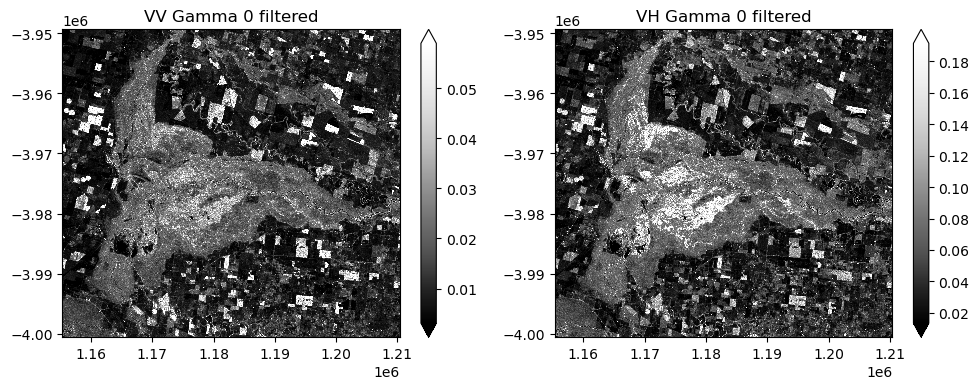

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ds_timestep = ds.isel(time=0)

ds_timestep["VH_gamma0_filtered"].plot.imshow(ax=ax[0], cmap="Greys_r", robust=True, add_labels=False)
ds_timestep["VV_gamma0_filtered"].plot.imshow(ax=ax[1], cmap="Greys_r", robust=True, add_labels=False)
ax[0].set_title('VV Gamma 0 filtered')
ax[1].set_title('VH Gamma 0 filtered');
plt.tight_layout();

## Radar False Colour

In [10]:
# median values are used to scale the measurements so they have a similar range for visualization
med_s1_filt = ds[['VV_gamma0_filtered','VH_gamma0_filtered','VHmVV_gamma0_filtered']].median()

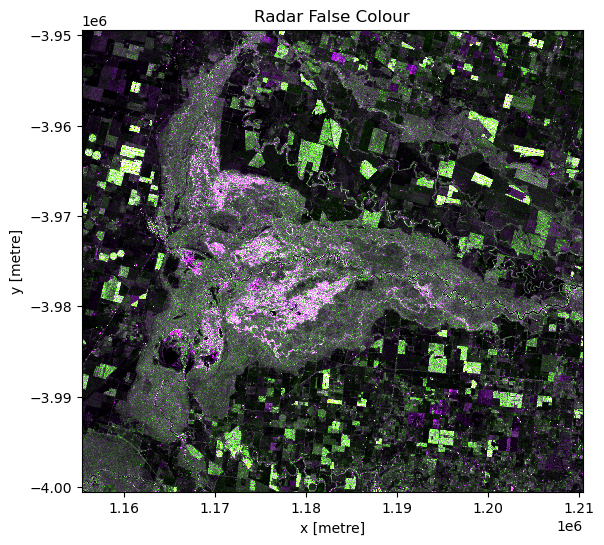

In [11]:
# plotting an RGB image for selected timesteps
rgb(ds[['VV_gamma0_filtered', 'VH_gamma0_filtered', 'VHmVV_gamma0_filtered']]/med_s1_filt, bands=['VV_gamma0_filtered',
    'VH_gamma0_filtered', 'VHmVV_gamma0_filtered'], index=0);
plt.title('Radar False Colour');

### Masking

The GA Sentinel-1 backscatter product comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.

#### Applying the mask

Apply the mask to create a new band, `VV_gamma0_filtered_masked`, that keeps the original `VV_gamma0_filtered` values where the mask is equal to 0, and replaces values with NaN otherwise.

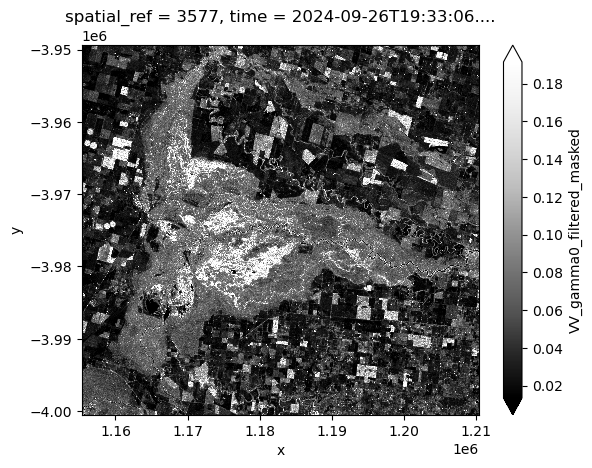

In [12]:
ds["VV_gamma0_filtered_masked"] = xr.where(ds.mask==0, ds["VV_gamma0_filtered"], np.nan)
ds["VH_gamma0_filtered_masked"] = xr.where(ds.mask==0, ds["VH_gamma0_filtered"], np.nan)

ds["VV_gamma0_filtered_masked"].isel(time=0).plot.imshow(cmap="Greys_r", robust=True)

### Converting to decibels

The conversion equation is 
$$\text{backscatter}_{\text{dB}} = 10 \times \log_{10}(\text{backscatter}_\text{linear})$$

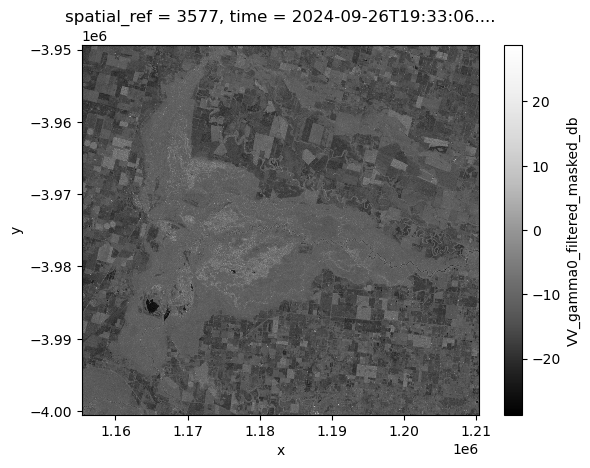

In [13]:
ds["VV_gamma0_filtered_masked_db"] = 10*np.log10(ds["VV_gamma0_filtered_masked"])
ds["VH_gamma0_filtered_masked_db"] = 10*np.log10(ds["VH_gamma0_filtered_masked"])

ds["VV_gamma0_filtered_masked_db"].squeeze().plot.imshow(cmap="Greys_r");

### Select area for defining water threshold

We need a small area with at least >1/3 open water for histogram thresholding.

In [14]:
aoi_bbox_sub = BoundingBox(
    left=144.911,
    bottom=-35.967,
    right=145.002,
    top=-35.908,
    crs="EPSG:4326"
)

In [15]:
# latitude=(aoi_bbox_sub.bottom, aoi_bbox_sub.top)
# longitude=(aoi_bbox_sub.left, aoi_bbox_sub.right)
# display_map(x=longitude, y=latitude)

In [16]:
stac_items = stac_client.search(
    collections=[product_to_load],
    datetime=f"{start_date}/{end_date}",
    bbox=aoi_bbox.bbox,
).item_collection()

print(f"Found {len(stac_items)} items")

ds_sub = load(
    items=stac_items,
    bands=measurements_to_load,
    intersects=aoi_bbox_sub.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby="solar_day",
    chunks={},
)

Found 12 items


In [17]:
# Apply specke filter to subset
ds_sub["VV_gamma0_filtered"] = apply_lee_filter(ds_sub["VV_gamma0"], size=5)
ds_sub["VH_gamma0_filtered"] = apply_lee_filter(ds_sub["VH_gamma0"], size=5)

# Convert to dB
ds_sub["VV_gamma0_filtered_db"] = 10*np.log10(ds_sub["VV_gamma0_filtered"])
ds_sub["VH_gamma0_filtered_db"] = 10*np.log10(ds_sub["VH_gamma0_filtered"])

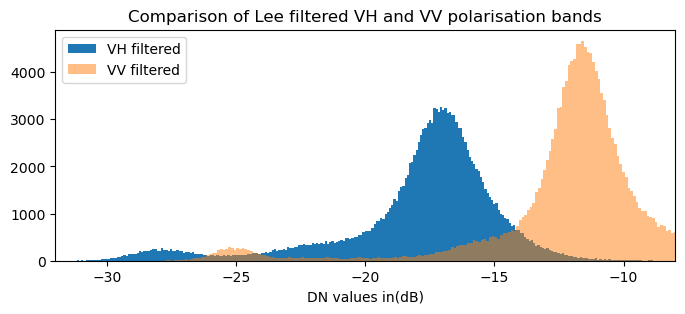

In [18]:
fig = plt.figure(figsize=(8, 3))
ds_sub.VH_gamma0_filtered_db[0].plot.hist(bins=300, label="VH filtered")
ds_sub.VV_gamma0_filtered_db[0].plot.hist(bins=300, label="VV filtered",alpha=0.5)
plt.xlim(-32,-8)
plt.legend()
plt.xlabel("DN values in(dB)")
plt.title("Comparison of Lee filtered VH and VV polarisation bands");

In [19]:
valid = np.isfinite(ds_sub)
ds_sub = ds_sub.where(valid, 0)

In [20]:
# calculate threshold using minimum method
threshold_vh = threshold_minimum(ds_sub.VH_gamma0_filtered_db[0].values)
threshold_vv = threshold_minimum(ds_sub.VV_gamma0_filtered_db[0].values)

# calculate threshold using otsu method
#threshold_vh = threshold_otsu(ds_sub.VH_gamma0_filtered_db[0].values)
#threshold_vv = threshold_otsu(ds_sub.VV_gamma0_filtered_db[0].values)

print('vh, vv threshold =', threshold_vh, threshold_vv)

vh, vv threshold = -25.585781 -20.847809


In [21]:
# Apply water threshold to full scene
ds["water"] = xr.where(ds["VH_gamma0_filtered_masked_db"]<threshold_vh, 1,0)

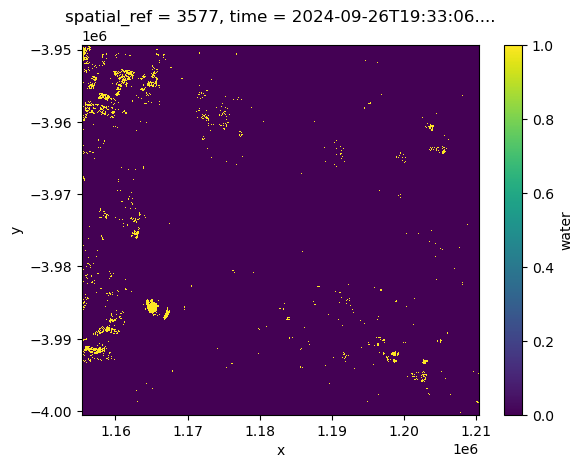

In [22]:
ds.water.plot();

### Load dry image

If flooded vegetation is not obvious in a single image, you can try the difference between the flooded and a dry image

In [23]:
start_date_dry = "2025-01-01"
end_date_dry = "2025-01-31"


stac_items = stac_client.search(
    collections=[product_to_load],
    datetime=f"{start_date_dry}/{end_date_dry}",
    bbox=aoi_bbox.bbox,
).item_collection()

print(f"Found {len(stac_items)} items")

ds_dry = load(
    items=stac_items,
    bands=measurements_to_load,
    intersects=aoi_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby="solar_day",
    chunks={},
)

Found 42 items


In [24]:
ds_dry = ds_dry.compute()

In [25]:
# Filter dry images
ds_dry["VV_gamma0_filtered"] = apply_lee_filter(ds_dry["VV_gamma0"], size=5)
ds_dry["VH_gamma0_filtered"] = apply_lee_filter(ds_dry["VH_gamma0"], size=5)
ds_dry["VHmVV_gamma0_filtered"] = ds_dry.VH_gamma0_filtered-ds_dry.VV_gamma0_filtered

In [26]:
# select scenes covering at least 50% of the area
total_px=len(ds_dry.x)*len(ds_dry.y)
valid=ds_dry.where(ds_dry.VV_gamma0_filtered!=0).where(ds_dry.VH_gamma0_filtered!=0).count(dim=('x','y'))
good=(valid.VH_gamma0_filtered/total_px)>0.8
ds_dry = ds_dry.sel(time=good)

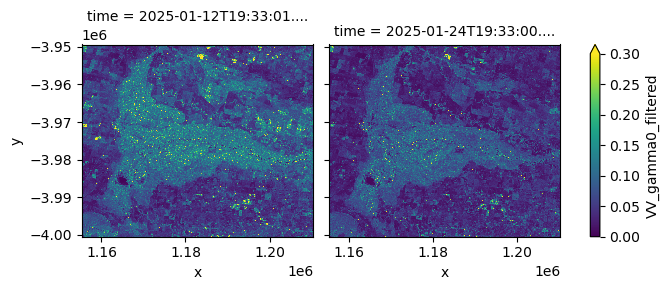

In [27]:
ds_dry.VV_gamma0_filtered.plot(col='time',vmin=0,vmax=0.3)

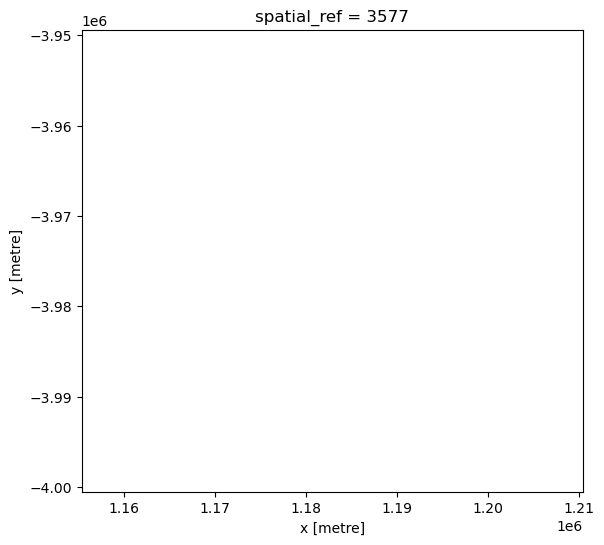

In [29]:
med_s1_dry_filt_month = ds_dry[['VV_gamma0_filtered','VH_gamma0_filtered','VHmVV_gamma0_filtered']].median(dim='time')
# plotting an RGB image for selected timesteps
rgb(med_s1_dry_filt_month[['VV_gamma0_filtered', 'VH_gamma0_filtered', 'VHmVV_gamma0_filtered']]/med_s1_dry_filt_month, bands=['VV_gamma0_filtered',
    'VH_gamma0_filtered', 'VHmVV_gamma0_filtered']);

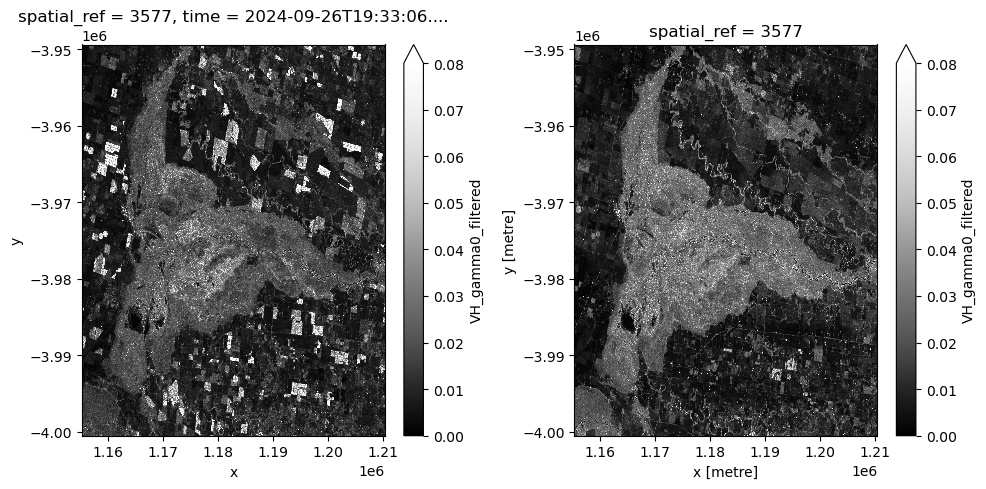

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ds["VH_gamma0_filtered"].isel(time=0).plot(ax=axes[0], cmap="Greys_r", robust=True, vmin=0,vmax=0.08)
med_s1_dry_filt_month['VH_gamma0_filtered'].plot(ax=axes[1], cmap="Greys_r", robust=True, vmin=0,vmax=0.08)

plt.tight_layout()
plt.show()

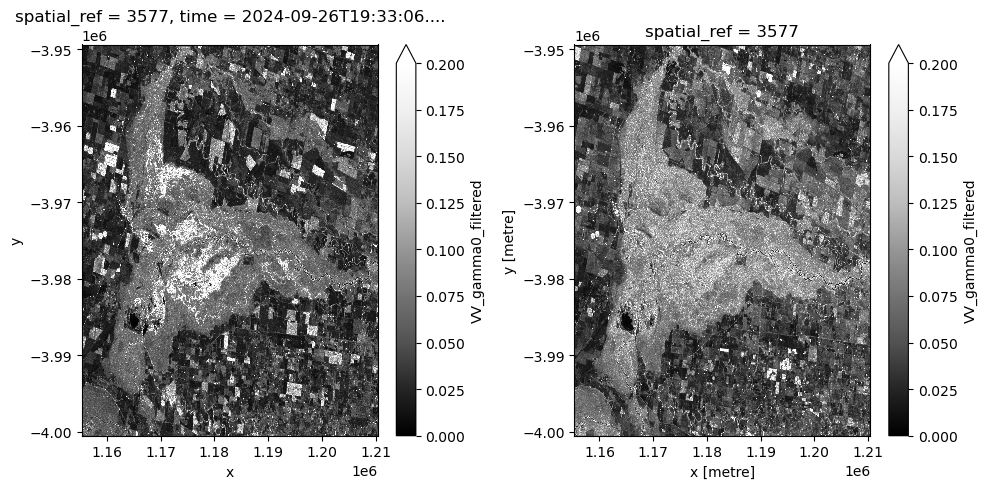

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ds["VV_gamma0_filtered"].isel(time=0).plot(ax=axes[0], cmap="Greys_r", robust=True, vmin=0,vmax=0.2)
med_s1_dry_filt_month['VV_gamma0_filtered'].plot(ax=axes[1], cmap="Greys_r", robust=True, vmin=0,vmax=0.2)

plt.tight_layout()
plt.show()

In [32]:
# Take the difference between 'dry' and flood image for best polaristion
ds_diff_VV = ds.VV_gamma0_filtered[0] - med_s1_dry_filt_month.VV_gamma0_filtered
ds_diff_VH = ds.VH_gamma0_filtered[0] - med_s1_dry_filt_month.VH_gamma0_filtered


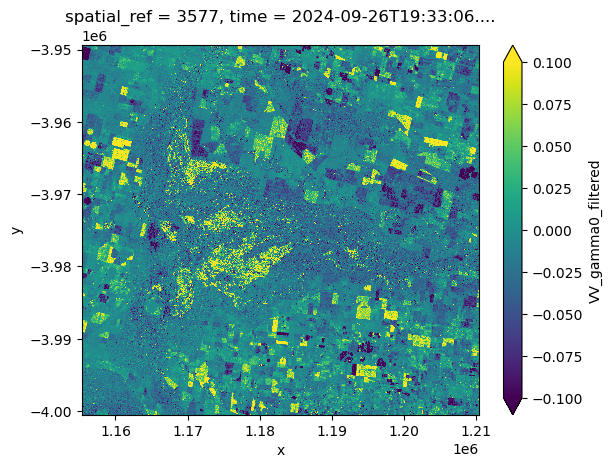

In [33]:
ds_diff_VV.plot(vmin=-0.1,vmax=0.1);
#ds_diff_VH.plot(vmin=-0.1,vmax=0.1)

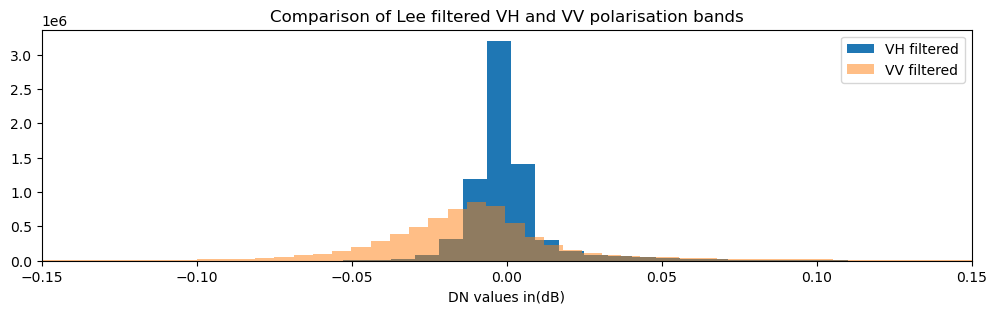

In [34]:
fig = plt.figure(figsize=(12, 3))
ds_diff_VH.plot.hist(bins=1000, label="VH filtered")
ds_diff_VV.plot.hist(bins=10000, label="VV filtered",alpha=0.5)
plt.xlim(-0.15,0.15)
plt.legend()
plt.xlabel("DN values in(dB)")
plt.title("Comparison of Lee filtered VH and VV polarisation bands");

### Subset area for flooded vegetation to calculate threshold

Need to select a small area with >1/3 flooded vegetation for histogram thresholding

In [35]:
aoi_bbox_subV = BoundingBox(
    left=145.071,
    bottom=-35.896,
    right=145.146,
    top=-35.846,
    crs="EPSG:4326"
)

In [36]:
# latitude=(aoi_bbox_subV.bottom, aoi_bbox_subV.top)
# longitude=(aoi_bbox_subV.left, aoi_bbox_subV.right)
# display_map(x=longitude, y=latitude)

In [37]:
stac_items = stac_client.search(
    collections=[product_to_load],
    datetime=f"{start_date}/{end_date}",
    bbox=aoi_bbox_subV.bbox,
).item_collection()

print(f"Found {len(stac_items)} items")

ds_subV = load(
    items=stac_items,
    bands=measurements_to_load,
    intersects=aoi_bbox_subV.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby="solar_day",
    chunks={},
)

Found 5 items


In [38]:
# Apply specke filter to subset
ds_subV["VV_gamma0_filtered"] = apply_lee_filter(ds_subV["VV_gamma0"], size=5)
ds_subV["VH_gamma0_filtered"] = apply_lee_filter(ds_subV["VH_gamma0"], size=5)

# Convert to dB
ds_subV["VV_gamma0_filtered_db"] = 10*np.log10(ds_subV["VV_gamma0_filtered"])
ds_subV["VH_gamma0_filtered_db"] = 10*np.log10(ds_subV["VH_gamma0_filtered"])

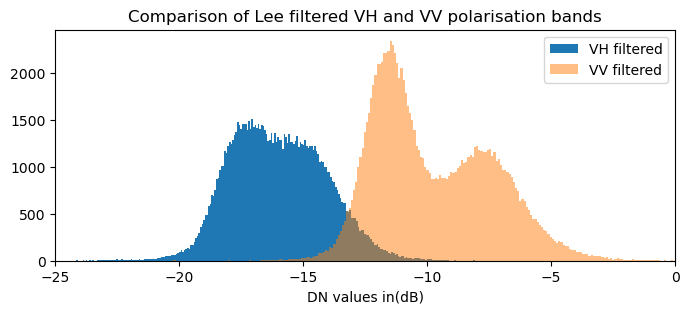

In [39]:
fig = plt.figure(figsize=(8, 3))
ds_subV.VH_gamma0_filtered_db[0].plot.hist(bins=300, label="VH filtered")
ds_subV.VV_gamma0_filtered_db[0].plot.hist(bins=300, label="VV filtered",alpha=0.5)
plt.xlim(-25,0)
plt.legend()
plt.xlabel("DN values in(dB)")
plt.title("Comparison of Lee filtered VH and VV polarisation bands");

In [40]:
valid = np.isfinite(ds_subV)
ds_subV = ds_subV.where(valid, 0)

In [41]:
# calculate threshold using minimum method
#threshold_vhV = threshold_minimum(ds_subV.VH_gamma0_filtered_db[0].values)
#threshold_vvV = threshold_minimum(ds_subV.VV_gamma0_filtered_db[0].values)

# calculate threshold using otsu method
threshold_vhV = threshold_otsu(ds_subV.VH_gamma0_filtered_db[0].values)
threshold_vvV = threshold_otsu(ds_subV.VV_gamma0_filtered_db[0].values)

print('vh, vv threshold =', threshold_vhV, threshold_vvV)

vh, vv threshold = -15.940794 -9.410173


In [42]:
ds["water_veg"] = xr.where(ds["VV_gamma0_filtered_masked_db"]>threshold_vvV, 1,0)

### Combine open water and flooded vegetation into single band

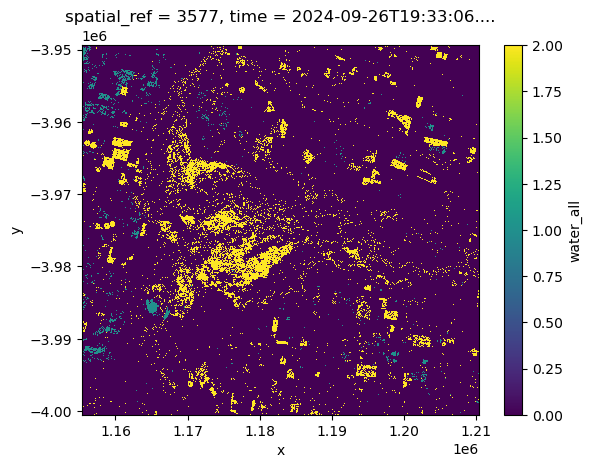

In [43]:
ds["water_all"] = xr.where(ds["water"]==1, 1,0)
ds["water_all"] = xr.where(ds["water_veg"]==1, 2, ds.water_all)

ds.water_all.plot()

### Apply morphological filter to remove small 'clumps' of water

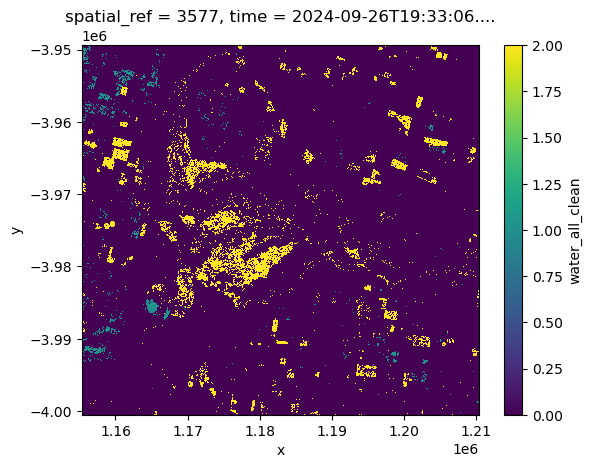

In [44]:
import skimage

footprint = skimage.morphology.disk(1)
opened = skimage.morphology.opening(ds.water_all.data[0], footprint)

ds['water_all_clean'] = ds.water_all * 0
ds.water_all_clean.data[0] = opened

ds.water_all_clean.plot();
#plt.imshow(opened)

#### Select output folder

In [45]:
# output_path = pathlib.Path("outputs")
# output_path.mkdir(exist_ok=True)

#### Exporting all time steps as Cloud Optimised GeoTIFFs

In [46]:
# ds_datetime_strings = ds.time.dt.strftime("%Y-%m-%d").values

# for timestep in range(len(ds.time)):
#     filename = output_path / f"OW_FV_trim_Barmah_{ds_datetime_strings[timestep]}.tif"
#     ds["water_all_clean"].astype(np.int16).isel(time=timestep).odc.write_cog(filename, overwrite=True)

#     filename = output_path / f"OW_FV_Barmah_{ds_datetime_strings[timestep]}.tif"
#     ds["water_all"].astype(np.int16).isel(time=timestep).odc.write_cog(filename, overwrite=True)